In [1]:
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

In [2]:
adata = sc.read_h5ad('../../data/figure-inputs/scrna_objects/pretx-plasma-paga.h5ad', backed='r')

In [3]:
# Map plasma states to colors
state_colors = adata.uns["plasma_labels_l3_colors"]
states = adata.obs["plasma_labels_l3"].cat.categories
color_dict = dict(zip(states, state_colors))

plot_data = adata.obs[["subject.subjectGuid", "plasma_labels_l3"]].copy()
subjects_sorted = sorted(plot_data["subject.subjectGuid"].unique())

# % of total cells per subject for side bar
subject_counts = plot_data["subject.subjectGuid"].value_counts()
subject_proportions = (subject_counts / len(plot_data) * 100).loc[subjects_sorted]

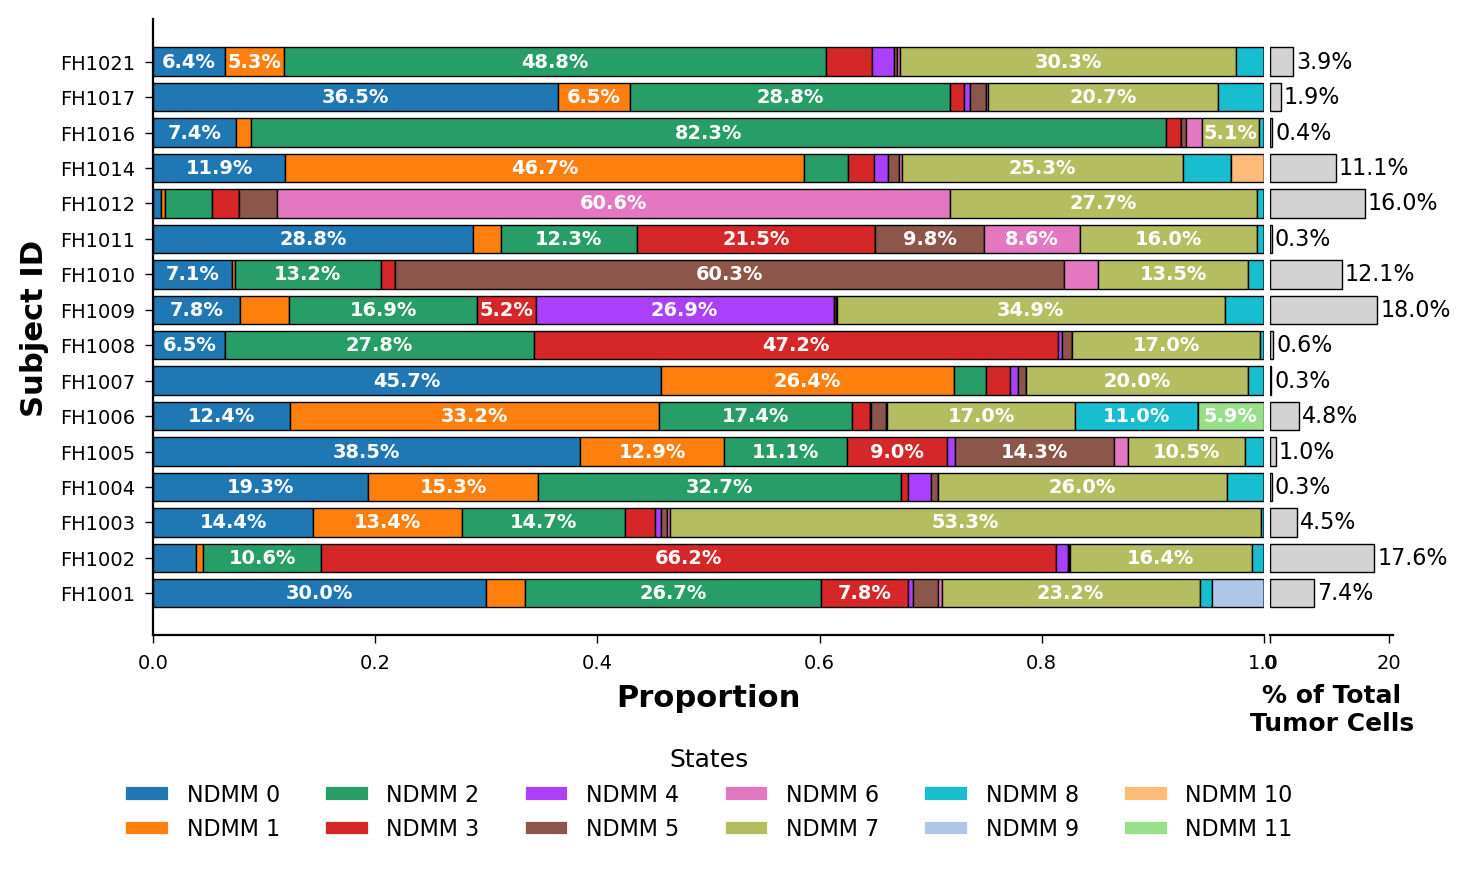

In [4]:
fig = plt.figure(figsize=(8, 4), dpi=200)
gs = fig.add_gridspec(1, 2, width_ratios=[4.5, 0.5], wspace=0.01)
ax_main = fig.add_subplot(gs[0])
ax_side = fig.add_subplot(gs[1])

# Stacked horizontal bars per subject
for subject in subjects_sorted:
    subset = plot_data[plot_data["subject.subjectGuid"] == subject]
    props = subset["plasma_labels_l3"].value_counts(normalize=True).sort_index()
    bottom = 0
    for state, prop in props.items():
        ax_main.barh(subject, prop, left=bottom, color=color_dict[state], edgecolor="black", linewidth=0.5)
        if prop > 0.05:  # label segments >5%
            ax_main.text(bottom + prop / 2, subject, f"{prop*100:.1f}%",
                         ha="center", va="center", fontsize=7, fontweight="bold", color="white")
        bottom += prop

ax_main.set_xlabel("Proportion", fontsize=11, fontweight="semibold")
ax_main.set_ylabel("Subject ID", fontsize=11, fontweight="semibold")
ax_main.set_xlim(0, 1)
ax_main.spines[["top", "right"]].set_visible(False)
ax_main.grid(visible=False)

# Side bar: total cell contribution per subject
ax_side.barh(subjects_sorted, subject_proportions.values, color="lightgray", edgecolor="black", linewidth=0.5)
for subject, pct in zip(subjects_sorted, subject_proportions.values):
    ax_side.text(pct + 0.5, subject, f"{pct:.1f}%", va="center", fontsize=8)
ax_side.set_xlabel("% of Total\nTumor Cells", fontsize=9, fontweight="semibold")
ax_side.set_xlim(0, subject_proportions.max() * 1.15)
ax_side.set_yticks([])
ax_side.grid(visible=False)
ax_side.spines[["top", "right", "left"]].set_visible(False)

# Legend below main plot
legend_elements = [mpatches.Patch(facecolor=color_dict[s], edgecolor="white", label=s, linewidth=1) for s in states]
ax_main.legend(handles=legend_elements, loc="upper center", bbox_to_anchor=(0.5, -0.15),
               ncol=min(6, len(states)), frameon=False, fontsize=8, title="States", title_fontsize=9)

ax_main.tick_params(axis='both', labelsize=7, length=3, width=0.5)
ax_side.tick_params(axis='both', labelsize=7, length=3, width=0.5)

In [5]:
fig.savefig("../../data/figure-outputs/figure-2/fig_2d.pdf", format="pdf", dpi=200, bbox_inches="tight")